<a href="https://colab.research.google.com/github/HasanovChE/Handwritten-Digit-Classifier-with-a-CNN-MNIST/blob/main/Handwritten_Digit_Classifier_with_a_CNN_(MNIST).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Step 1 — Install libraries**

In this step, we install the necessary libraries in Google Colab and import them into our project.

In [ ]:
!pip install -q torch torchvision tensorflow matplotlib seaborn scikit-learn pillow fastapi
uvicorn python-multipart

In [ ]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
confusion_matrix,
classification_report,
accuracy_score
)
from PIL import Image, ImageOps

print("PyTorch:", torch.version)
print("TensorFlow:", tf.version)

PyTorch: <module 'torch.version' from '/usr/local/lib/python3.13/dist-packages/torch/version.py'>
TensorFlow: <module 'tensorflow._api.v2.version' from '/usr/local/lib/python3.13/dist-packages/tensorflow/_api/v2/version/__init__.py'>


**Step 2. Reproducibility**

In professional machine learning projects, setting a "random seed" is essential to ensure that results are consistent (reproducible) every time. At this stage, we also specify the device (CPU or GPU) for PyTorch.

In [ ]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
tf.random.set_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
print("Random seed:", SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

Random seed: 42
Device: cuda


**Step 3. MNIST loading**



In [ ]:
from tensorflow.keras.datasets import mnist

(x_train_full, y_train_full), (x_test, y_test) = mnist.load_data()

print("Original train:", x_train_full.shape)
print("Original test:", x_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Original train: (60000, 28, 28)
Original test: (10000, 28, 28)


**Step 4. Explicit train/validation/test split**

In [ ]:
x_train, x_val, y_train, y_val = train_test_split(
    x_train_full,
    y_train_full,
    test_size=10000,
    random_state=SEED,
    stratify=y_train_full
)

print("Train:", x_train.shape)
print("Validation:", x_val.shape)
print("Test:", x_test.shape)

Train: (50000, 28, 28)
Validation: (10000, 28, 28)
Test: (10000, 28, 28)


**Step 5. Normalize**

In [ ]:
x_train = x_train.astype(np.float32) / 255.0
x_val = x_val.astype(np.float32) / 255.0
x_test = x_test.astype(np.float32) / 255.0

**Step 6. Dataset visualization**

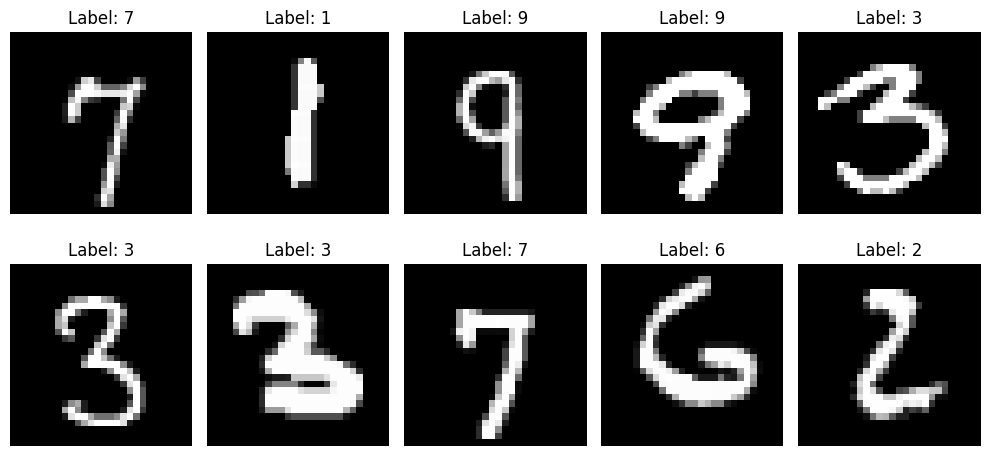

In [ ]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(x_train[i], cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

**Step 7. PyTorch data preparation**

In [ ]:
x_train_torch = torch.tensor(x_train).unsqueeze(1)
x_val_torch = torch.tensor(x_val).unsqueeze(1)
x_test_torch = torch.tensor(x_test).unsqueeze(1)

y_train_torch = torch.tensor(y_train, dtype=torch.long)
y_val_torch = torch.tensor(y_val, dtype=torch.long)
y_test_torch = torch.tensor(y_test, dtype=torch.long)

print(x_train_torch.shape)

torch.Size([50000, 1, 28, 28])


**Step 8. PyTorch DataLoader**


In [ ]:
from torch.utils.data import TensorDataset, DataLoader

BATCH_SIZE = 128

train_dataset = TensorDataset(x_train_torch, y_train_torch)
val_dataset = TensorDataset(x_val_torch, y_val_torch)
test_dataset = TensorDataset(x_test_torch, y_test_torch)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

**Step 9. PyTorch CNN**

In [ ]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Dropout(0.25),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

cnn_torch = CNN().to(DEVICE)
print(cnn_torch)

CNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3136, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.25, inplace=False)
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
)


**Step 10. PyTorch MLP Baseline**

In [ ]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 128),
            nn.ReLU(),
            nn.Dropout(0.25),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 10)
        )

    def forward(self, x):
        return self.network(x)

mlp_torch = MLP().to(DEVICE)
print(mlp_torch)

MLP(
  (network): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.25, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): ReLU()
    (6): Linear(in_features=64, out_features=10, bias=True)
  )
)


**Step 11. PyTorch Training**

In [ ]:
EPOCHS = 10
LEARNING_RATE = 0.001

def train_model(model, train_loader, val_loader, epochs=10):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": []
    }

    for epoch in range(epochs):
        # TRAIN
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_loss = running_loss / total
        train_acc = correct / total

        # VALIDATION
        model.eval()
        val_loss_total = 0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(DEVICE)
                labels = labels.to(DEVICE)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss_total += loss.item() * images.size(0)
                _, predicted = torch.max(outputs, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        val_loss = val_loss_total / val_total
        val_acc = val_correct / val_total

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(
            f"Epoch {epoch+1}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_acc:.4f}"
        )

    return history

# Train PyTorch CNN
print("Training PyTorch CNN...")
cnn_history_torch = train_model(cnn_torch, train_loader, val_loader, epochs=EPOCHS)

# Train PyTorch MLP
print("\nTraining PyTorch MLP...")
mlp_history_torch = train_model(mlp_torch, train_loader, val_loader, epochs=EPOCHS)

Training PyTorch CNN...
Epoch 1/10 | Train Loss: 0.3449 | Train Acc: 0.8931 | Val Loss: 0.0811 | Val Acc: 0.9771
Epoch 2/10 | Train Loss: 0.0848 | Train Acc: 0.9743 | Val Loss: 0.0532 | Val Acc: 0.9840
Epoch 3/10 | Train Loss: 0.0587 | Train Acc: 0.9821 | Val Loss: 0.0462 | Val Acc: 0.9867
Epoch 4/10 | Train Loss: 0.0479 | Train Acc: 0.9852 | Val Loss: 0.0437 | Val Acc: 0.9864
Epoch 5/10 | Train Loss: 0.0390 | Train Acc: 0.9881 | Val Loss: 0.0442 | Val Acc: 0.9878
Epoch 6/10 | Train Loss: 0.0321 | Train Acc: 0.9895 | Val Loss: 0.0411 | Val Acc: 0.9881
Epoch 7/10 | Train Loss: 0.0283 | Train Acc: 0.9905 | Val Loss: 0.0419 | Val Acc: 0.9881
Epoch 8/10 | Train Loss: 0.0256 | Train Acc: 0.9913 | Val Loss: 0.0426 | Val Acc: 0.9881
Epoch 9/10 | Train Loss: 0.0223 | Train Acc: 0.9929 | Val Loss: 0.0469 | Val Acc: 0.9865
Epoch 10/10 | Train Loss: 0.0199 | Train Acc: 0.9934 | Val Loss: 0.0409 | Val Acc: 0.9883

Training PyTorch MLP...
Epoch 1/10 | Train Loss: 0.5030 | Train Acc: 0.8554 | Val Lo

**Step 12. PyTorch Evaluation**

In [ ]:
def evaluate_pytorch(model, test_loader):
    model.eval()
    correct = 0
    total = 0
    predictions = []
    targets = []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            predictions.extend(predicted.cpu().numpy())
            targets.extend(labels.cpu().numpy())

    accuracy = correct / total
    return accuracy, np.array(targets), np.array(predictions)

# CNN Evaluation
cnn_acc_torch, y_true, y_pred = evaluate_pytorch(cnn_torch, test_loader)
print(f"PyTorch CNN Test Accuracy: {cnn_acc_torch:.4%}")

# MLP Evaluation
mlp_acc_torch, _, mlp_pred = evaluate_pytorch(mlp_torch, test_loader)
print(f"PyTorch MLP Test Accuracy: {mlp_acc_torch:.4%}")

PyTorch CNN Test Accuracy: 99.1000%
PyTorch MLP Test Accuracy: 97.6200%


**Step 13. TensorFlow CNN**

In [ ]:
# TensorFlow məlumat hazırlığı
x_train_tf = x_train[..., np.newaxis]
x_val_tf = x_val[..., np.newaxis]
x_test_tf = x_test[..., np.newaxis]

print("TensorFlow Train Shape:", x_train_tf.shape)

# TensorFlow CNN Arxitekturası
cnn_tf = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28, 28, 1)),
    tf.keras.layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.25),
    tf.keras.layers.Dense(10, activation="softmax")
])

# Modelin kompayl edilməsi
cnn_tf.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

TensorFlow Train Shape: (50000, 28, 28, 1)


**Step 14. TensorFlow MLP**

In [ ]:
mlp_tf = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28, 28)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.25),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax")
])

mlp_tf.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

**Step 15. TensorFlow Training**

In [ ]:
# TensorFlow CNN təlimi
tf_history_cnn = cnn_tf.fit(
    x_train_tf,
    y_train,
    validation_data=(x_val_tf, y_val),
    epochs=10,
    batch_size=128,
    shuffle=True,
    verbose=1
)

# TensorFlow MLP təlimi
tf_history_mlp = mlp_tf.fit(
    x_train,
    y_train,
    validation_data=(x_val, y_val),
    epochs=10,
    batch_size=128,
    shuffle=True,
    verbose=1
)

Epoch 1/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - accuracy: 0.9281 - loss: 0.2420 - val_accuracy: 0.9791 - val_loss: 0.0688
Epoch 2/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9792 - loss: 0.0667 - val_accuracy: 0.9775 - val_loss: 0.0685
Epoch 3/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9851 - loss: 0.0491 - val_accuracy: 0.9877 - val_loss: 0.0437
Epoch 4/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9882 - loss: 0.0377 - val_accuracy: 0.9877 - val_loss: 0.0440
Epoch 5/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9911 - loss: 0.0291 - val_accuracy: 0.9879 - val_loss: 0.0400
Epoch 6/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9925 - loss: 0.0247 - val_accuracy: 0.9899 - val_loss: 0.0372
Epoch 7/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9928 - loss: 0.0218 - val_accuracy: 0.9877 - val_loss: 0.0456
Epoch 8/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9941 - loss: 0.0179 - val_accuracy: 

**Step 16. TensorFlow Evaluation**

In [ ]:
cnn_tf_results = cnn_tf.evaluate(
    x_test_tf,
    y_test,
    verbose=0
)

mlp_tf_results = mlp_tf.evaluate(
    x_test,
    y_test,
    verbose=0
)

print("TensorFlow CNN:", cnn_tf_results)
print("TensorFlow MLP:", mlp_tf_results)

TensorFlow CNN: [0.03128425031900406, 0.9918000102043152]
TensorFlow MLP: [0.08206424862146378, 0.9769999980926514]


**Step 17. CNN vs MLP Comparison Visualization**

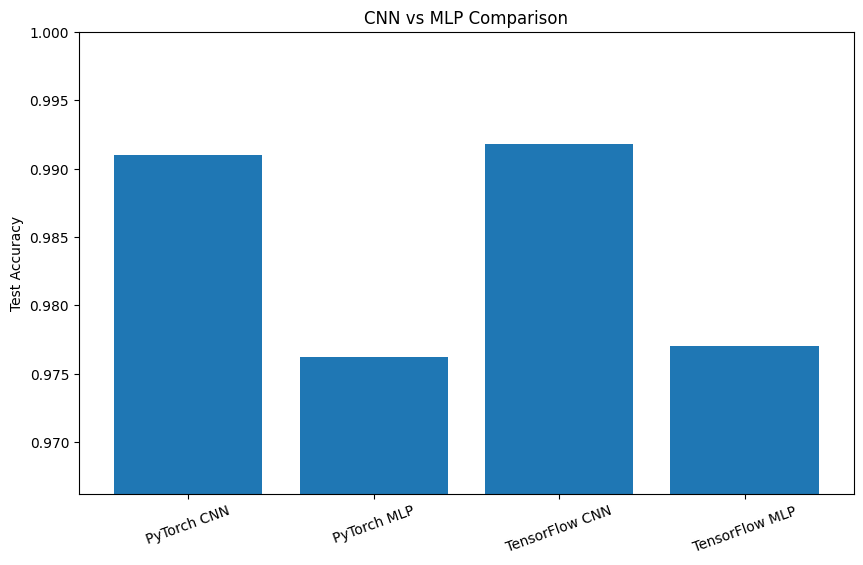

In [ ]:
models = [
    "PyTorch CNN",
    "PyTorch MLP",
    "TensorFlow CNN",
    "TensorFlow MLP"
]

accuracies = [
    cnn_acc_torch,
    mlp_acc_torch,
    cnn_tf_results[1],
    mlp_tf_results[1]
]

plt.figure(figsize=(10,6))
plt.bar(models, accuracies)
plt.ylabel("Test Accuracy")
plt.title("CNN vs MLP Comparison")
plt.ylim(min(accuracies) - 0.01, 1.0)
plt.xticks(rotation=20)
plt.show()

**Step 18. Confusion Matrix**

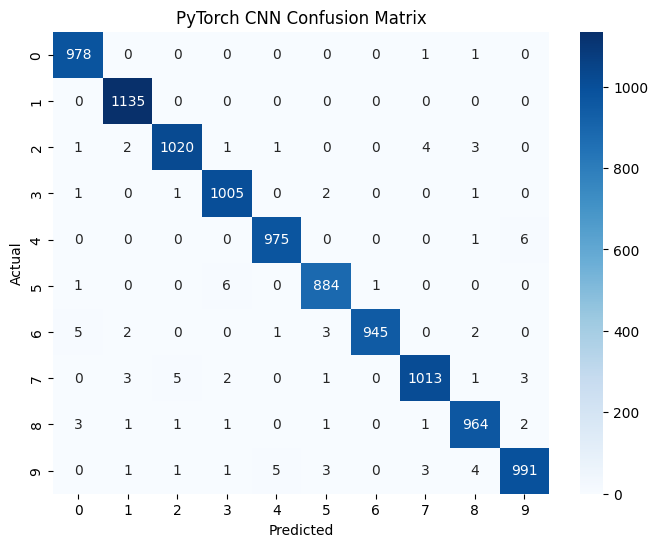

In [ ]:
cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("PyTorch CNN Confusion Matrix")
plt.show()

**Step 19. Most confused digit pair**

In [ ]:
cm_without_diag = cm.copy()
np.fill_diagonal(cm_without_diag, 0)

max_index = np.unravel_index(
    np.argmax(cm_without_diag),
    cm_without_diag.shape
)
digit_a, digit_b = max_index

print("Most confused pair:", digit_a, "and", digit_b)
print("Confusions:", cm_without_diag[digit_a, digit_b])

Most confused pair: 4 and 9
Confusions: 6


**Step 20. Custom image preprocessing (Real handwriting test)**

In [ ]:
def preprocess_custom_image(path):
    image = Image.open(path)
    # Grayscale
    image = image.convert("L")
    # Resize
    image = image.resize((28, 28))
    # Invert
    image = ImageOps.invert(image)
    # Convert to numpy
    image = np.array(image)
    # Normalize
    image = image.astype(np.float32) / 255.0

    return image

**Step 21. Visualize preprocessing**

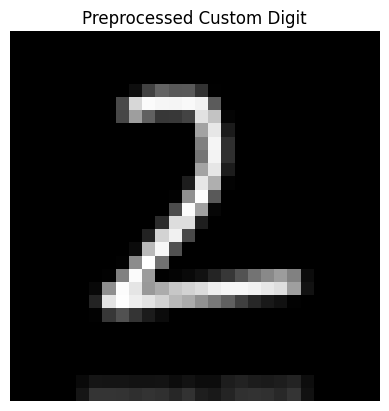

In [ ]:
import requests
import io

image_url = "https://www.shutterstock.com/image-photo/two-number-art-calligraphy-handwritten-260nw-2798523789.jpg"
response = requests.get(image_url)
img_data = io.BytesIO(response.content)
img = preprocess_custom_image(img_data)

plt.imshow(img, cmap="gray")
plt.title("Preprocessed Custom Digit")
plt.axis("off")
plt.show()

**Step 22. Custom inference TensorFlow**

In [ ]:
def predict_custom_tf(model, image_path):
    image = preprocess_custom_image(image_path)
    input_image = image.reshape(1, 28, 28, 1)

    probabilities = model.predict(input_image, verbose=0)[0]
    prediction = np.argmax(probabilities)
    confidence = probabilities[prediction]

    return prediction, confidence


prediction, confidence = predict_custom_tf(cnn_tf, img_data)

print(
    f"Actual: {2} | "
    f"Predicted: {prediction} | "
    f"Confidence: {confidence:.2%}"
)

Actual: 2 | Predicted: 2 | Confidence: 99.99%


**Step 23. Model Persistence**

In [ ]:
# PyTorch Model Persistence
torch.save(cnn_torch.state_dict(), "pytorch_cnn.pth")

loaded_cnn = CNN().to(DEVICE)
loaded_cnn.load_state_dict(
    torch.load("pytorch_cnn.pth", map_location=DEVICE)
)
loaded_cnn.eval()

accuracy_loaded, _, _ = evaluate_pytorch(loaded_cnn, test_loader)
print("Loaded model accuracy:", accuracy_loaded)


# TensorFlow Model Persistence
cnn_tf.save("tensorflow_cnn.keras")

loaded_tf_cnn = tf.keras.models.load_model("tensorflow_cnn.keras")

loaded_tf_cnn.evaluate(x_test_tf, y_test, verbose=1)

Loaded model accuracy: 0.991
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9918 - loss: 0.0313


[0.03128425031900406, 0.9918000102043152]

**Step 24. Separate inference script**

In [ ]:
# predict_tensorflow.py
import numpy as np
from PIL import Image, ImageOps
import tensorflow as tf
import requests
import io

MODEL_PATH = "tensorflow_cnn.keras"
model = tf.keras.models.load_model(MODEL_PATH)

def preprocess_image(image_input):
    # Check if the input is a URL string
    if isinstance(image_input, str) and image_input.startswith("http"):
        response = requests.get(image_input)
        image = Image.open(io.BytesIO(response.content))
    else:
        # Assume it's a local file path or a file-like object already
        image = Image.open(image_input)

    image = image.convert("L")
    image = image.resize((28, 28))
    image = ImageOps.invert(image)
    image = np.array(image, dtype=np.float32) / 255.0
    image = image.reshape(1, 28, 28, 1)
    return image

image = preprocess_image("https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcR1eYrAwTkbLj9f5hGdQ4t7Tkl3lUlYGqd_heL1Nh0xDg&s=10")
prediction = model.predict(image, verbose=0)

digit = np.argmax(prediction)
confidence = np.max(prediction)

print(f"Prediction: {digit}")
print(f"Confidence: {confidence:.2%}")

Prediction: 2
Confidence: 99.99%


**Step 25. FastAPI Implementation**

In [ ]:
# api/app.py
from fastapi import FastAPI, UploadFile, File
import numpy as np
from PIL import Image, ImageOps
import tensorflow as tf

app = FastAPI(title="MNIST Digit Classifier API")

model = tf.keras.models.load_model("../models/tensorflow_cnn.keras")

def preprocess_image(image):
    image = image.convert("L")
    image = image.resize((28, 28))
    image = ImageOps.invert(image)
    image = np.array(image, dtype=np.float32) / 255.0
    image = image.reshape(1, 28, 28, 1)
    return image

@app.get("/")
def root():
    return {"message": "MNIST CNN Digit Classifier"}

@app.post("/predict")
async def predict(file: UploadFile = File(...)):
    image = Image.open(file.file)
    processed = preprocess_image(image)

    probabilities = model.predict(processed, verbose=0)[0]
    digit = int(np.argmax(probabilities))
    confidence = float(np.max(probabilities))

    return {
        "digit": digit,
        "confidence": confidence
    }

**Step 26. Learned Filters Visualization**

Filter shape: (3, 3, 1, 32)


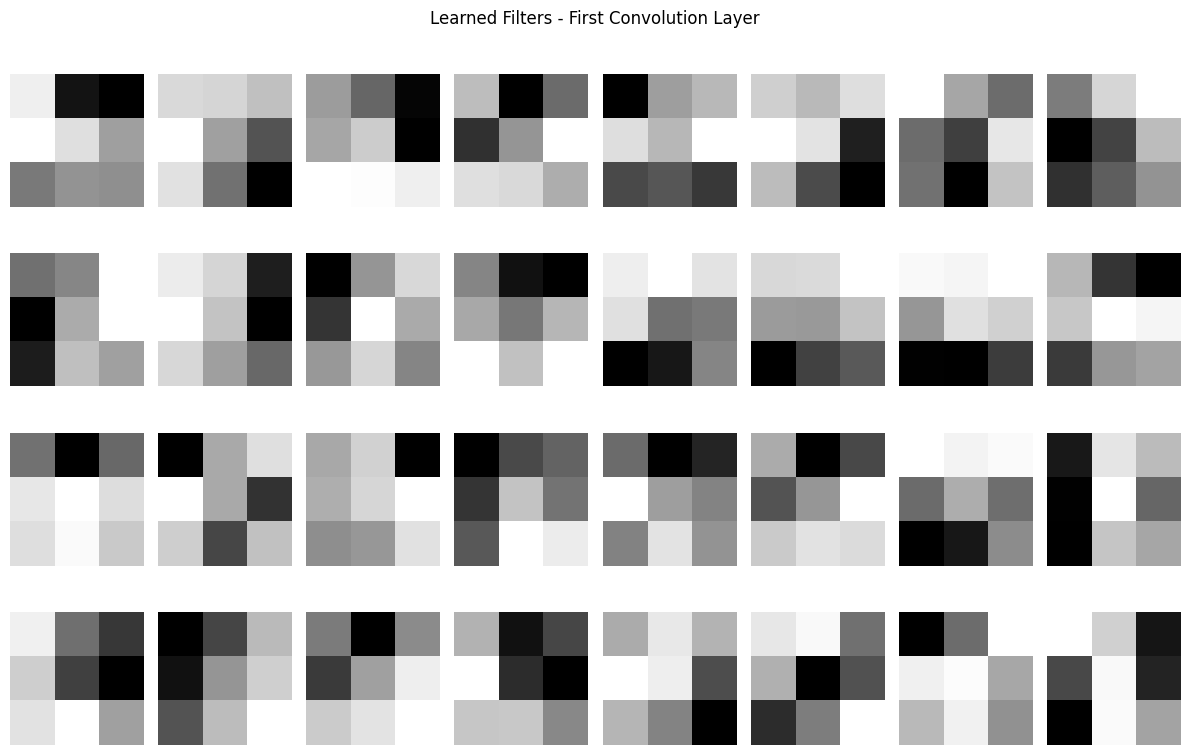

In [ ]:
filters = loaded_tf_cnn.weights[0]
biases = loaded_tf_cnn.weights[1]

print("Filter shape:", filters.shape)

plt.figure(figsize=(12, 8))
for i in range(32):
    plt.subplot(4, 8, i + 1)
    plt.imshow(filters[:, :, 0, i], cmap="gray")
    plt.axis("off")

plt.suptitle("Learned Filters - First Convolution Layer")
plt.tight_layout()
plt.show()

**Step 27. Data Augmentation Experiment**

In [ ]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomRotation(0.08),
    tf.keras.layers.RandomTranslation(0.1, 0.1)
])

cnn_aug = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28, 28, 1)),
    data_augmentation,
    tf.keras.layers.Conv2D(32, 3, padding="same", activation="relu"),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(64, 3, padding="same", activation="relu"),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.25),
    tf.keras.layers.Dense(10, activation="softmax")
])

cnn_aug.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_aug = cnn_aug.fit(
    x_train_tf,
    y_train,
    validation_data=(x_val_tf, y_val),
    epochs=10,
    batch_size=128
)

Epoch 1/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.8260 - loss: 0.5393 - val_accuracy: 0.9650 - val_loss: 0.1108
Epoch 2/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9349 - loss: 0.2104 - val_accuracy: 0.9761 - val_loss: 0.0757
Epoch 3/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9525 - loss: 0.1541 - val_accuracy: 0.9819 - val_loss: 0.0596
Epoch 4/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9613 - loss: 0.1298 - val_accuracy: 0.9831 - val_loss: 0.0535
Epoch 5/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9634 - loss: 0.1162 - val_accuracy: 0.9849 - val_loss: 0.0495
Epoch 6/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9685 - loss: 0.1047 - val_accuracy: 0.9849 - val_loss: 0.0486
Epoch 7/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9708 - loss: 0.0956 - val_accuracy: 0.9841 - val_loss: 0.0517
Epoch 8/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9737 - loss: 0.0866 - val_accuracy: 

**Step 28. Batch Normalization Experiment**

In [ ]:
cnn_bn = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28, 28, 1)),
    tf.keras.layers.Conv2D(32, 3, padding="same"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.ReLU(),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(64, 3, padding="same"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.ReLU(),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.ReLU(),
    tf.keras.layers.Dropout(0.25),
    tf.keras.layers.Dense(10, activation="softmax")
])

**Step 29. Batch Normalization Training and Evaluation**

In [ ]:
cnn_bn.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_bn = cnn_bn.fit(
    x_train_tf,
    y_train,
    validation_data=(x_val_tf, y_val),
    epochs=10,
    batch_size=128,
    verbose=1
)

bn_results = cnn_bn.evaluate(x_test_tf, y_test, verbose=0)
print(f"Batch Normalization CNN Test Accuracy: {bn_results[1]:.4%}")

Epoch 1/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.9620 - loss: 0.1388 - val_accuracy: 0.1745 - val_loss: 3.1145
Epoch 2/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9870 - loss: 0.0449 - val_accuracy: 0.9641 - val_loss: 0.1117
Epoch 3/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9915 - loss: 0.0288 - val_accuracy: 0.9864 - val_loss: 0.0441
Epoch 4/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9947 - loss: 0.0194 - val_accuracy: 0.9840 - val_loss: 0.0493
Epoch 5/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9956 - loss: 0.0155 - val_accuracy: 0.9882 - val_loss: 0.0415
Epoch 6/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9965 - loss: 0.0123 - val_accuracy: 0.9873 - val_loss: 0.0461
Epoch 7/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9974 - loss: 0.0093 - val_accuracy: 0.9798 - val_loss: 0.0718
Epoch 8/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9972 - loss: 0.0092 - val_accuracy: 

**Step 30. Comprehensive Experiment Summary & Comparison**

              Model  Test Accuracy
2   TF Baseline CNN         0.9918
0       PyTorch CNN         0.9910
5  TF BatchNorm CNN         0.9888
4  TF Augmented CNN         0.9862
3            TF MLP         0.9770
1       PyTorch MLP         0.9762


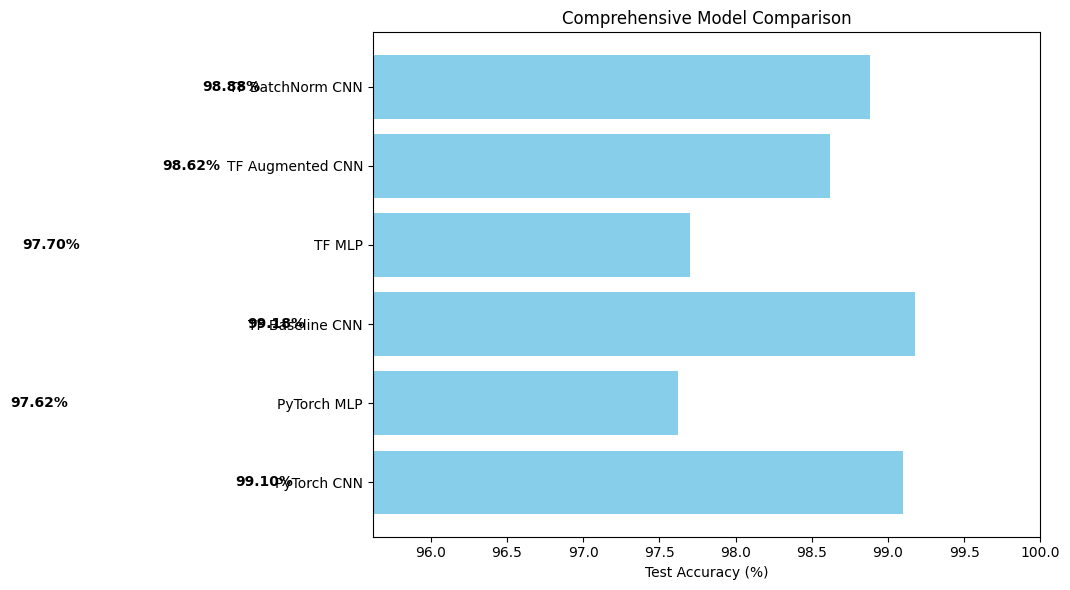

In [ ]:
import pandas as pd

experiment_results = {
    "Model": [
        "PyTorch CNN",
        "PyTorch MLP",
        "TF Baseline CNN",
        "TF MLP",
        "TF Augmented CNN",
        "TF BatchNorm CNN"
    ],
    "Test Accuracy": [
        cnn_acc_torch,
        mlp_acc_torch,
        cnn_tf_results[1],
        mlp_tf_results[1],
        history_aug.history['val_accuracy'][-1], # və ya test evaluation nəticəsi
        bn_results[1]
    ]
}

df_results = pd.DataFrame(experiment_results)
print(df_results.sort_values(by="Test Accuracy", ascending=False))

plt.figure(figsize=(12, 6))
bars = plt.barh(df_results["Model"], df_results["Test Accuracy"] * 100, color='skyblue')
plt.xlabel("Test Accuracy (%)")
plt.title("Comprehensive Model Comparison")
plt.xlim(min(df_results["Test Accuracy"] * 100) - 2, 100)

for bar in bars:
    width = bar.get_width()
    plt.text(width - 4, bar.get_y() + bar.get_height()/2, f'{width:.2f}%',
             va='center', ha='right', color='black', fontweight='bold')

plt.tight_layout()
plt.show()